### DataFrame 구조

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../Data/auto-mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [4]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name
393,27.0,4,140.0,86.00,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.00,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.00,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.00,2625.0,18.6,82,1,ford ranger
397,31.0,4,119.0,82.00,2720.0,19.4,82,1,chevy s-10


#### 자동차 연비 DataSet
- mpg(miles per galon) : 연비(국내는 kpl: kilometer per liter)
- cylinders : 실린더수
- displacement : 배기량
- horsepower : 마력
- weight : 차중
- acceleration : 가속능력
- model : 출시년도
- origin : 제조국(1: USA, 2:EU, 3:JPN)
- name : 모델명


In [5]:
# df의 크기(모양)

df.shape

(398, 9)

In [6]:
# df의 자료형
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [7]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.00,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.00,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.00,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.00,2625.0,18.6,82,1,ford ranger


In [8]:
# 기본 통계량
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [ ]:
# df의 origin의 고유값과 갯수 확인
df.origin.unique()
df.origin.value_counts() # 빈도수 확인

origin
1    249
3     79
2     70
Name: count, dtype: int64

In [23]:
# 평균값
print(df.mean(numeric_only=True))
print("-"*20)

# df의 mpg만 평균
print(df.mpg.mean())
print(df['mpg'].mean())
print("-"*20)

# df의 mpg와 weight의 평균 구하기
print(df.mpg.mean(), df.weight.mean())

mpg               23.514573
cylinders          5.454774
displacement     193.425879
weight          2970.424623
acceleration      15.568090
model year        76.010050
origin             1.572864
dtype: float64
--------------------
23.514572864321607
23.514572864321607
--------------------
23.514572864321607 2970.424623115578


# 상관계수
- 0 ~ 0.3 : 상관없음
- 0.3 ~ 0.5 : 미미한 상관이 있음
- 0.5 ~ 0.7 : 상관이 있음
- 0.7 ~ : 높은 상관성

In [78]:
# mpg와 weight의 상관계수
# 상관계수는 정렬을 하면 안된다. 그러면 무조건 상관계수가 수치가 올라간다.  

df.loc[:,['mpg', 'weight']].corr()

,mpg,weight
mpg,1.000000,-0.831741
weight,-0.831741,1.000000


In [79]:
df.corr(numeric_only=True) # mpg와 관련이 가장 높은 건 weight / cylinders와 관련이 가장 높은 건 displacement

,mpg,cylinders,displacement,weight,acceleration,model year,origin
mpg,1.000000,-0.775396,-0.804203,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.932824,-0.543684,-0.370164,-0.609409
weight,-0.831741,0.896017,0.932824,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.417457,1.000000,0.288137,0.205873
model year,0.579267,-0.348746,-0.370164,-0.306564,0.288137,1.000000,0.180662
origin,0.563450,-0.562543,-0.609409,-0.581024,0.205873,0.180662,1.000000


---
### Pandas 내장 그래프 도구

In [27]:
df = pd.read_excel("../Data/남북한발전전력량.xlsx")
df.head()

,전력량 (억㎾h),발전 전력별,1990,1991,1992,1993,1994,1995,1996,1997,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,남한,합계,1077,1186,1310,1444,1650,1847,2055,2244,...,4031,4224,4336,4747,4969,5096,5171,5220,5281,5404
1,NaN,수력,64,51,49,60,41,55,52,54,...,50,56,56,65,78,77,84,78,58,66
2,NaN,화력,484,573,696,803,1022,1122,1264,1420,...,2551,2658,2802,3196,3343,3430,3581,3427,3402,3523
3,NaN,원자력,529,563,565,581,587,670,739,771,...,1429,1510,1478,1486,1547,1503,1388,1564,1648,1620
4,NaN,신재생,-,-,-,-,-,-,-,-,...,-,-,-,-,-,86,118,151,173,195


In [28]:
df.shape

(9, 29)

In [45]:
# 남한, 북한 발전량 합계 부분만 발췌

df_sn = df.loc[[0,5],'1990':]
df_sn.index = ['South', 'North']
df_sn

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
South,1077,1186,1310,1444,1650,1847,2055,2244,2153,2393,...,4031,4224,4336,4747,4969,5096,5171,5220,5281,5404
North,277,263,247,221,231,230,213,193,170,186,...,236,255,235,237,211,215,221,216,190,239


In [46]:
df_sn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, South to North
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   1990    2 non-null      object
 1   1991    2 non-null      object
 2   1992    2 non-null      object
 3   1993    2 non-null      object
 4   1994    2 non-null      object
 5   1995    2 non-null      object
 6   1996    2 non-null      object
 7   1997    2 non-null      object
 8   1998    2 non-null      object
 9   1999    2 non-null      object
 10  2000    2 non-null      object
 11  2001    2 non-null      object
 12  2002    2 non-null      object
 13  2003    2 non-null      object
 14  2004    2 non-null      object
 15  2005    2 non-null      object
 16  2006    2 non-null      object
 17  2007    2 non-null      object
 18  2008    2 non-null      object
 19  2009    2 non-null      object
 20  2010    2 non-null      object
 21  2011    2 non-null      object
 22  2012    2 non-null      obj

In [49]:
# Data Type이 object이어서 int로 변환
df_sn = df_sn.astype('int')
df_sn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, South to North
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   1990    2 non-null      int64
 1   1991    2 non-null      int64
 2   1992    2 non-null      int64
 3   1993    2 non-null      int64
 4   1994    2 non-null      int64
 5   1995    2 non-null      int64
 6   1996    2 non-null      int64
 7   1997    2 non-null      int64
 8   1998    2 non-null      int64
 9   1999    2 non-null      int64
 10  2000    2 non-null      int64
 11  2001    2 non-null      int64
 12  2002    2 non-null      int64
 13  2003    2 non-null      int64
 14  2004    2 non-null      int64
 15  2005    2 non-null      int64
 16  2006    2 non-null      int64
 17  2007    2 non-null      int64
 18  2008    2 non-null      int64
 19  2009    2 non-null      int64
 20  2010    2 non-null      int64
 21  2011    2 non-null      int64
 22  2012    2 non-null      int64
 23  2013    2 non-nu

In [51]:
df_sn

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
South,1077,1186,1310,1444,1650,1847,2055,2244,2153,2393,...,4031,4224,4336,4747,4969,5096,5171,5220,5281,5404
North,277,263,247,221,231,230,213,193,170,186,...,236,255,235,237,211,215,221,216,190,239


<Axes: >

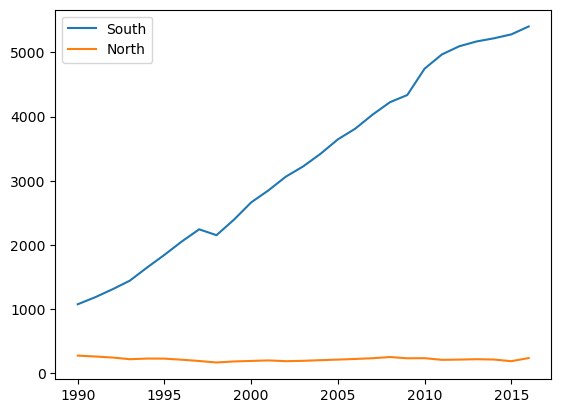

In [ ]:
df_sn.T.plot() # 선그래프는 추세를 보기 위해 쓴다.

In [54]:
df_sn.T

,South,North
1990,1077,277
1991,1186,263
1992,1310,247
1993,1444,221
1994,1650,231
1995,1847,230
1996,2055,213
1997,2244,193
1998,2153,170
1999,2393,186


<Axes: >

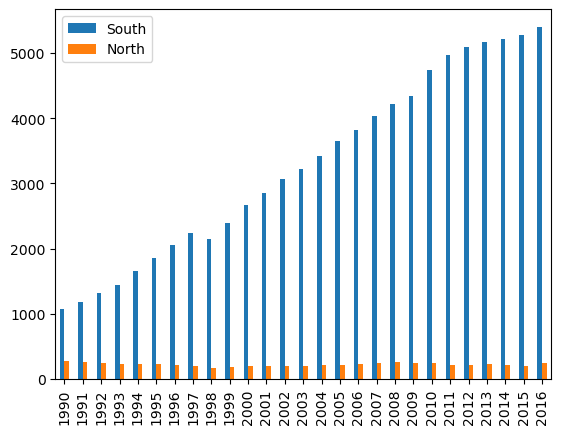

In [55]:
# 막대 그래프 # 그래프의 크기를 보기 위해 쓴다

df_sn.T.plot(
  kind='bar'
)


<Axes: ylabel='Frequency'>

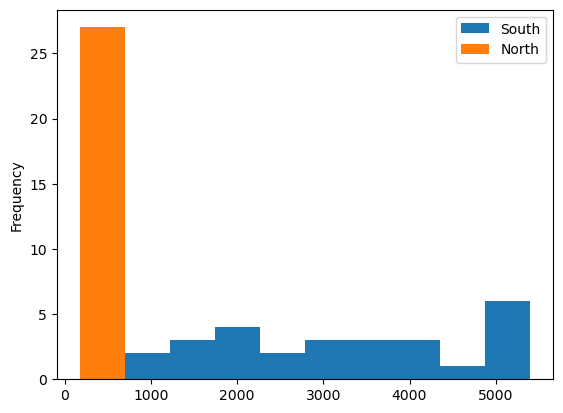

In [56]:
# 히스토그램 : 빈도수 (Frequency)
df_sn.T.plot(
  kind = 'hist'
)

In [57]:
# 산점도(산포도, Scatter) : 2개의 컬럼 데이터들의 관계를 표시
df = pd.read_csv("../Data/auto-mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [60]:
# mpg, weight의 상관계수
df.loc[:,['mpg','weight']].corr()

,mpg,weight
mpg,1.000000,-0.831741
weight,-0.831741,1.000000


<Axes: xlabel='weight', ylabel='mpg'>

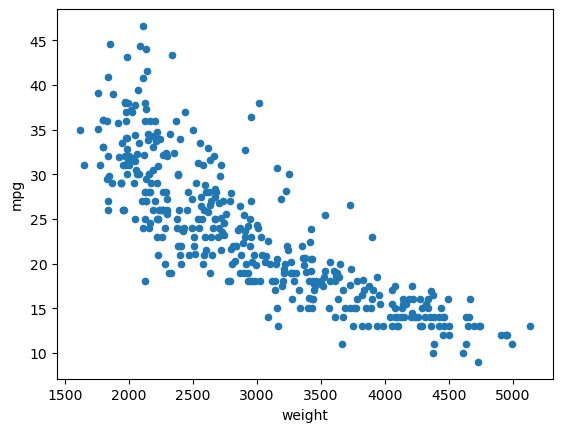

In [63]:
df.plot(
  kind='scatter',
  x='weight',
  y='mpg'
)

<Axes: >

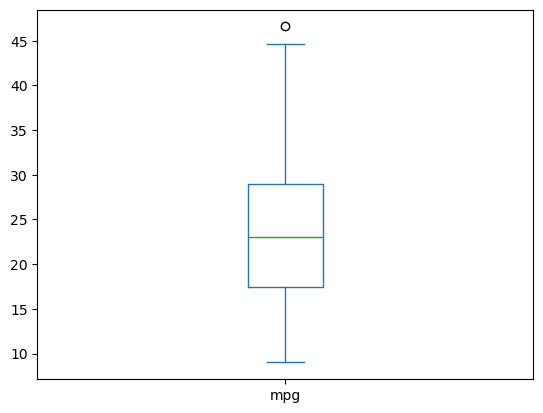

In [67]:
# 박스플롯(상자수염) : 이상치 확인
df.loc[:,'mpg'].plot(
  kind='box'
)

In [68]:
df.mpg.describe()

count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

In [75]:
df.mpg.quantile(1)

46.6

In [83]:
q1 = df.mpg.quantile(0.25)
q3 = df.mpg.quantile(0.75)

iqr = q3 - q1
whisker_max = q3 + 1.5 * iqr

boxplot_max = df.mpg[df.mpg <= whisker_max].max()
print(f"boxplot의 max (수염 위 끝): {boxplot_max}")

boxplot의 max (수염 위 끝): 44.6


In [90]:
q1 = df.mpg.quantile(0.25)
q3 = df.mpg.quantile(0.75)

iqr = q3 - q1

lower_bond = q1 - 1.5 * iqr
upper_bond = q3 + (1.5 * iqr)

filteraed = df[(df['mpg'] >= lower_bond) & (df['mpg'] <= upper_bond)]

# 경계 구하기
min_filteraed = filteraed['mpg'].min()
max_filteraed = filteraed['mpg'].max()

print(min_filteraed, max_filteraed)

9.0 44.6


In [87]:
# 이상치 데이터 추출 및 갯수 확인하기

# 이상치 조건: mpg < lower_bound 또는 mpg > upper_bound
outliers = df[(df['mpg'] < lower_bond) | (df['mpg'] > upper_bond)]

# 이상치 데이터 출력
print(outliers)

# 이상치 갯수 출력
print("이상치 갯수:", len(outliers))

      mpg  cylinders  displacement horsepower  weight  acceleration  \
322  46.6          4          86.0      65.00  2110.0          17.9   

     model year  origin       name  
322          80       3  mazda glc  
이상치 갯수: 1


<Axes: xlabel='weight', ylabel='mpg'>

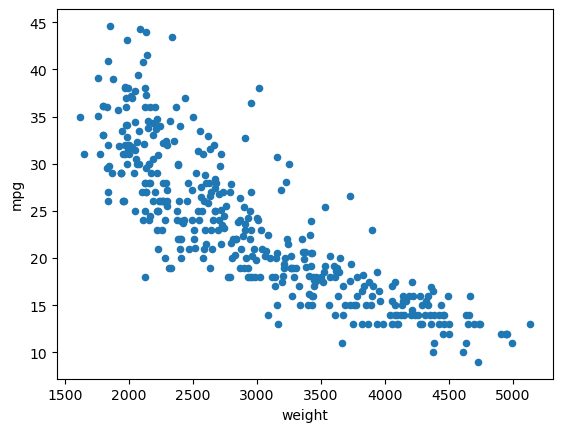

In [88]:
# 이상치를 제거한 데이터의 산포도 구하기

inliers = df[(df['mpg'] >= lower_bond) & (df['mpg'] <= upper_bond)]

inliers.plot(
  kind='scatter',
  x='weight',
  y='mpg'
)